# Pipeline v2 — Give Me Some Credit

Improvements over v1:
- Clean column names
- Delinquency feature engineering
- Regularization on all models
- Visual evaluation dashboard comparing all metrics

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline

---
## 2. Load Data

In [2]:
df = pd.read_csv(r'..\data\cs-training.csv', index_col=0)
print('Shape:', df.shape)
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


---
## 3. Rename Columns

The original column names are long, inconsistent, and have special characters. Clean names make the pipeline easier to read, debug, and deploy.

In [3]:
column_map = {
    'SeriousDlqin2yrs':                      'target',
    'RevolvingUtilizationOfUnsecuredLines':   'revolving_utilization',
    'age':                                    'age',
    'NumberOfTime30-59DaysPastDueNotWorse':   'delq_30_59',
    'DebtRatio':                              'debt_ratio',
    'MonthlyIncome':                          'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':        'open_credit_lines',
    'NumberOfTimes90DaysLate':                'delq_90plus',
    'NumberRealEstateLoansOrLines':           'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':   'delq_60_89',
    'NumberOfDependents':                     'dependents'
}

df = df.rename(columns=column_map)

print('Columns after renaming:')
print(df.columns.tolist())

Columns after renaming:
['target', 'revolving_utilization', 'age', 'delq_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'delq_90plus', 'real_estate_loans', 'delq_60_89', 'dependents']


---
## 4. Data Type Fixes

In [4]:
df['target'] = df['target'].astype(int)
df['age']    = df['age'].astype(int)

print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Dtypes:
target                     int64
revolving_utilization    float64
age                        int64
delq_30_59                 int64
debt_ratio               float64
monthly_income           float64
open_credit_lines          int64
delq_90plus                int64
real_estate_loans          int64
delq_60_89                 int64
dependents               float64
dtype: object

Missing values:
target                       0
revolving_utilization        0
age                          0
delq_30_59                   0
debt_ratio                   0
monthly_income           29731
open_credit_lines            0
delq_90plus                  0
real_estate_loans            0
delq_60_89                   0
dependents                3924
dtype: int64


---
## 5. Remove Known Data Errors

In [5]:
print('Rows before cleaning:', len(df))

df = df[df['age'] > 0]

for col in ['delq_30_59', 'delq_60_89', 'delq_90plus']:
    df = df[~df[col].isin([96, 98])]

df = df.drop_duplicates()

print('Rows after cleaning :', len(df))
print('Rows removed        :', 150000 - len(df))

Rows before cleaning: 150000
Rows after cleaning : 149165
Rows removed        : 835


---
## 6. Feature Engineering

### 6.1 Does the customer have any delinquency history?

A binary flag: 1 if the customer has at least one delinquency event of any severity, 0 otherwise. This captures whether someone has ever been late at all, regardless of how severe.

In [6]:
df['has_any_delq'] = (
    (df['delq_30_59'] > 0) |
    (df['delq_60_89'] > 0) |
    (df['delq_90plus'] > 0)
).astype(int)

print('has_any_delq distribution:')
print(df['has_any_delq'].value_counts())
print()

# Check default rate by flag
print('Default rate by has_any_delq:')
print(df.groupby('has_any_delq')['target'].mean().round(4))

has_any_delq distribution:
has_any_delq
0    119083
1     30082
Name: count, dtype: int64

Default rate by has_any_delq:
has_any_delq
0   0.0274
1   0.2199
Name: target, dtype: float64


### 6.2 Weighted delinquency severity score

Rather than keeping three separate columns that are highly correlated with each other, we combine them into one weighted score. A 90-day delinquency is more severe than a 60-day one, which is more severe than a 30-day one. The weights reflect this ordering.

This removes multicollinearity between the three delinquency columns while preserving all the information they contain.

In [7]:
df['delq_severity_score'] = (
    df['delq_30_59']  * 1 +
    df['delq_60_89']  * 2 +
    df['delq_90plus'] * 3
)

print('delq_severity_score summary:')
print(df['delq_severity_score'].describe())
print()

# Verify it separates the target
print('Mean severity score by target:')
print(df.groupby('target')['delq_severity_score'].mean().round(4))

delq_severity_score summary:
count   149165.0000
mean         0.6490
std          2.0858
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max         51.0000
Name: delq_severity_score, dtype: float64

Mean severity score by target:
target
0   0.4286
1   3.7593
Name: delq_severity_score, dtype: float64


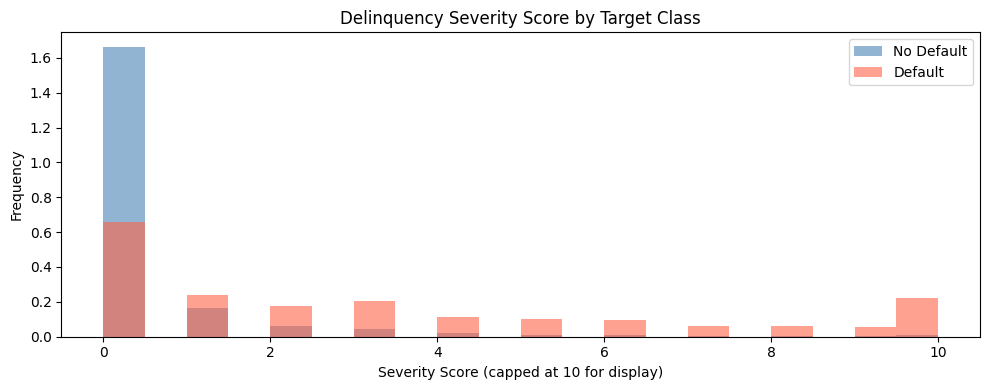

In [8]:
# Quick visual: severity score distribution by target class
fig, ax = plt.subplots(figsize=(10, 4))

df[df['target']==0]['delq_severity_score'].clip(upper=10).plot.hist(
    bins=20, alpha=0.6, color='steelblue', label='No Default', ax=ax, density=True)
df[df['target']==1]['delq_severity_score'].clip(upper=10).plot.hist(
    bins=20, alpha=0.6, color='tomato', label='Default', ax=ax, density=True)

ax.set_title('Delinquency Severity Score by Target Class')
ax.set_xlabel('Severity Score (capped at 10 for display)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Drop the original three delinquency columns

Now that we have `delq_severity_score` and `has_any_delq`, keeping the original three columns would introduce multicollinearity. They are replaced, not supplemented.

In [9]:
df = df.drop(columns=['delq_30_59', 'delq_60_89', 'delq_90plus'])

print('Final columns:')
print(df.columns.tolist())

Final columns:
['target', 'revolving_utilization', 'age', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'real_estate_loans', 'dependents', 'has_any_delq', 'delq_severity_score']


---
## 7. Train / Test Split

In [10]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print()
print('Target distribution in train:')
print(y_train.value_counts(normalize=True).round(4))

Train size: (119332, 9)
Test size : (29833, 9)

Target distribution in train:
target
0   0.9338
1   0.0662
Name: proportion, dtype: float64


---
## 8. Custom Transformers

In [11]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Caps each column at a given lower and upper percentile.
    Boundaries are computed from training data only.
    """
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.lower_pct)
        self.upper_bounds_ = X.quantile(self.upper_pct)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X.values

In [12]:
class MissingFlagAdder(BaseEstimator, TransformerMixin):
    """
    Adds a binary flag column for each specified column.
    1 = value was missing, 0 = value was present.
    Must run before imputation.
    """
    def __init__(self, cols_to_flag=None):
        self.cols_to_flag = cols_to_flag

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.cols_to_flag:
            for col in self.cols_to_flag:
                if col in X.columns:
                    X[str(col) + '_missing'] = X[col].isnull().astype(int)
        return X.values

In [13]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Applies log1p to columns whose skewness exceeds the threshold.
    Skewness is measured on training data only.
    Only applies to non-negative columns.
    """
    def __init__(self, threshold=1.0):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        skewness = X.skew()
        non_negative = (X.min() >= 0)
        self.cols_to_transform_ = skewness[
            (skewness.abs() > self.threshold) & non_negative
        ].index.tolist()
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.cols_to_transform_:
            if col in X.columns:
                X[col] = np.log1p(X[col])
        return X.values

---
## 9. Build Pipelines

All three models use `class_weight='balanced'` to handle the 93/7 imbalance. Logistic Regression uses L2 regularization (C=0.1 — stronger regularization than the default C=1). Random Forest limits tree depth to prevent any single feature from being over-used. Gradient Boosting uses a lower learning rate with more trees for more distributed learning.

In [14]:
COLS_TO_FLAG = ['monthly_income', 'dependents']

def build_pipeline(model):
    return Pipeline([
        ('flag_missing', MissingFlagAdder(cols_to_flag=COLS_TO_FLAG)),
        ('cap_outliers', OutlierCapper(lower_pct=0.01, upper_pct=0.99)),
        ('impute',       SimpleImputer(strategy='median')),
        ('fix_skewness', SkewnessTransformer(threshold=1.0)),
        ('scale',        StandardScaler()),
        ('model',        model)
    ])

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1,                    # stronger L2 regularization
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,              # limits how deep any single tree can go
        min_samples_leaf=50,      # requires meaningful support before splitting
        max_features='sqrt',      # each tree only sees a random subset of features
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,       # slower learning rate spreads influence more evenly
        max_depth=4,              # shallow trees force broader feature usage
        min_samples_leaf=50,
        subsample=0.8,            # random row sampling reduces variance
        max_features='sqrt',      # random feature sampling per split
        random_state=42
    )
}

print('Models and pipelines defined.')

Models and pipelines defined.


---
## 10. Train All Models

In [15]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training: {name} ...')
    pipe = build_pipeline(model)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline' : pipe,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'cv_auc'   : cv_auc,
        'test_auc' : roc_auc_score(y_test, y_prob),
        'f1'       : f1_score(y_test, y_pred, pos_label=1),
        'precision': precision_score(y_test, y_pred, pos_label=1),
        'recall'   : recall_score(y_test, y_pred, pos_label=1),
    }

    print(f'  CV AUC  : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')
    print(f'  Test AUC: {results[name]["test_auc"]:.4f}')
    print(f'  F1      : {results[name]["f1"]:.4f}')
    print(f'  Precision: {results[name]["precision"]:.4f}')
    print(f'  Recall  : {results[name]["recall"]:.4f}')
    print()

Training: Logistic Regression ...
  CV AUC  : 0.8586 (+/- 0.0037)
  Test AUC: 0.8512
  F1      : 0.3335
  Precision: 0.2157
  Recall  : 0.7352

Training: Random Forest ...
  CV AUC  : 0.8640 (+/- 0.0038)
  Test AUC: 0.8556
  F1      : 0.3378
  Precision: 0.2179
  Recall  : 0.7504

Training: Gradient Boosting ...
  CV AUC  : 0.8665 (+/- 0.0037)
  Test AUC: 0.8593
  F1      : 0.2751
  Precision: 0.5858
  Recall  : 0.1797



---
## 11. Evaluation Dashboard

### 11.1 Metric Comparison — All Models Side by Side

This chart shows all four metrics together. Use it to decide which model to pick based on what matters most for the business. For credit default, recall on the default class is usually the priority — missing a defaulter is more costly than a false alarm.

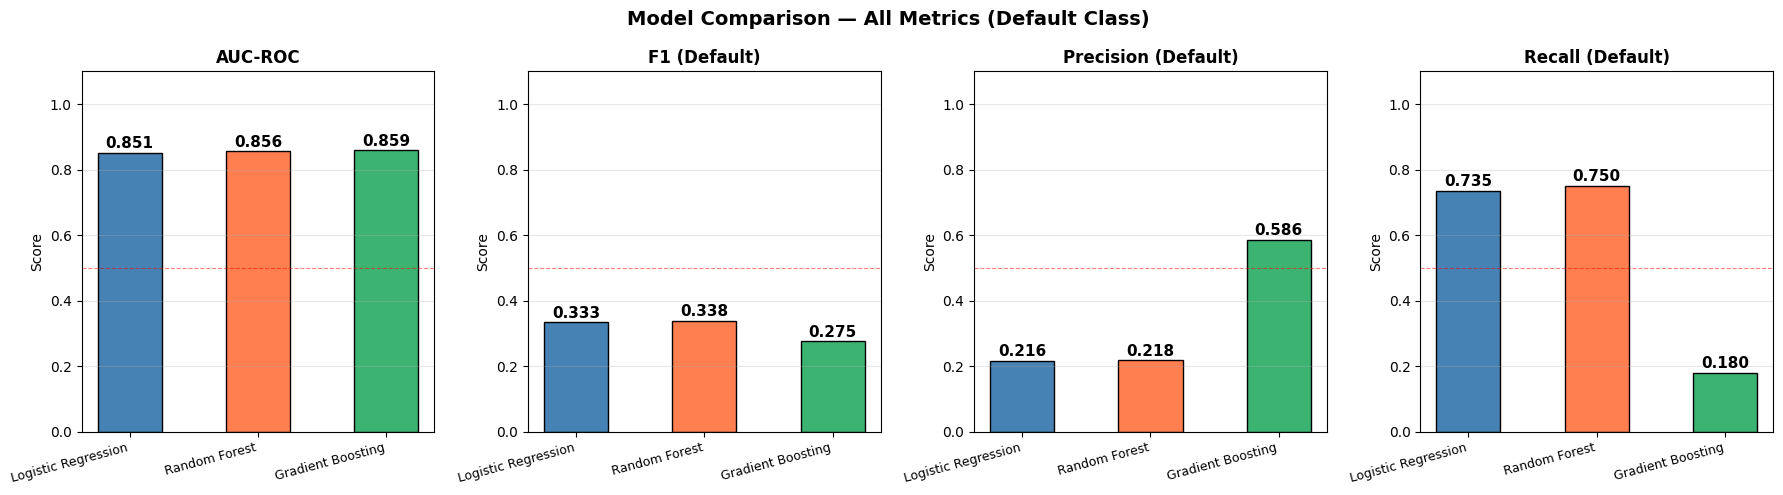

In [16]:
metric_names  = ['AUC-ROC', 'F1 (Default)', 'Precision (Default)', 'Recall (Default)']
metric_keys   = ['test_auc', 'f1', 'precision', 'recall']
model_names   = list(results.keys())
colors        = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison — All Metrics (Default Class)', fontsize=14, fontweight='bold')

for ax, metric_name, metric_key in zip(axes, metric_names, metric_keys):
    values = [results[m][metric_key] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', width=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

### 11.2 Precision vs Recall Trade-off

Precision and recall move in opposite directions as you change the decision threshold. This chart makes that trade-off visible. The vertical dashed line marks the default 0.5 threshold.

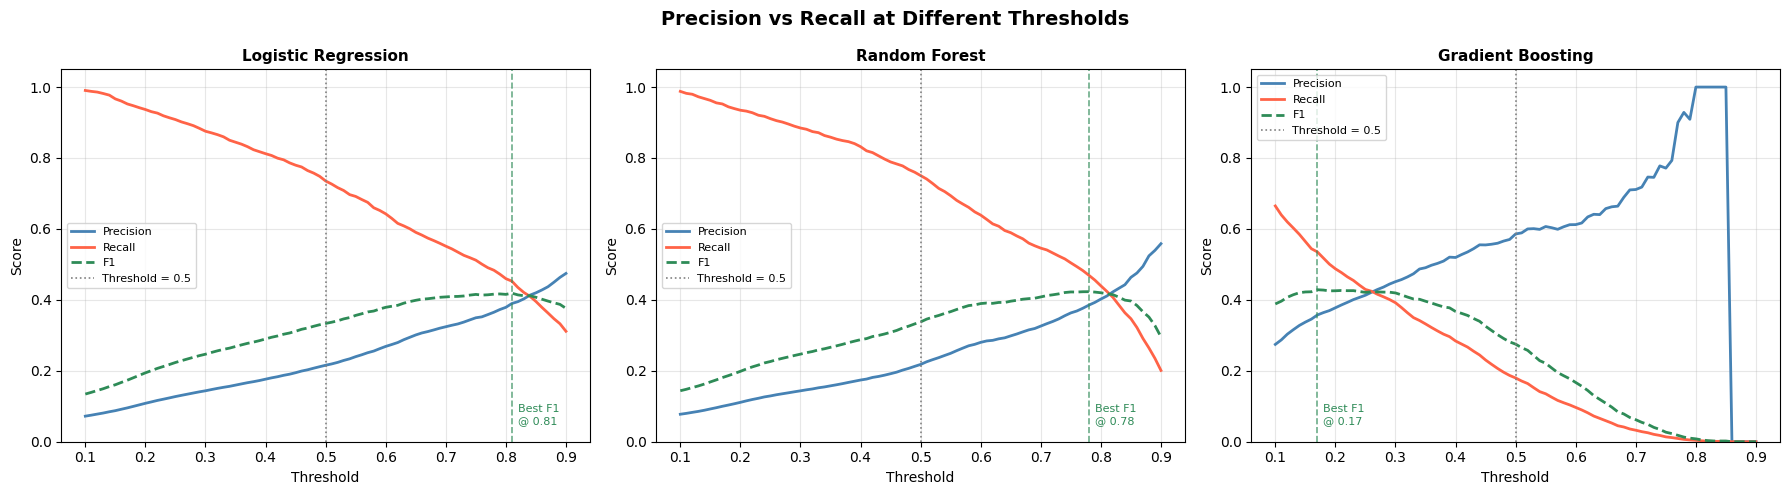

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Precision vs Recall at Different Thresholds', fontsize=14, fontweight='bold')

thresholds_range = np.arange(0.1, 0.91, 0.01)

for ax, (name, res) in zip(axes, results.items()):
    precisions, recalls, f1s = [], [], []

    for thresh in thresholds_range:
        y_pred_t = (res['y_prob'] >= thresh).astype(int)
        precisions.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))

    ax.plot(thresholds_range, precisions, label='Precision', color='steelblue',  linewidth=2)
    ax.plot(thresholds_range, recalls,    label='Recall',    color='tomato',     linewidth=2)
    ax.plot(thresholds_range, f1s,        label='F1',        color='seagreen',   linewidth=2, linestyle='--')
    ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.2, label='Threshold = 0.5')

    # Mark the threshold where F1 is highest
    best_thresh = thresholds_range[np.argmax(f1s)]
    best_f1     = max(f1s)
    ax.axvline(x=best_thresh, color='seagreen', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(best_thresh + 0.01, 0.05, f'Best F1\n@ {best_thresh:.2f}', fontsize=8, color='seagreen')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
!pip install streamlit

  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached protobuf-6.33.5-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Usin

### 11.3 ROC Curves

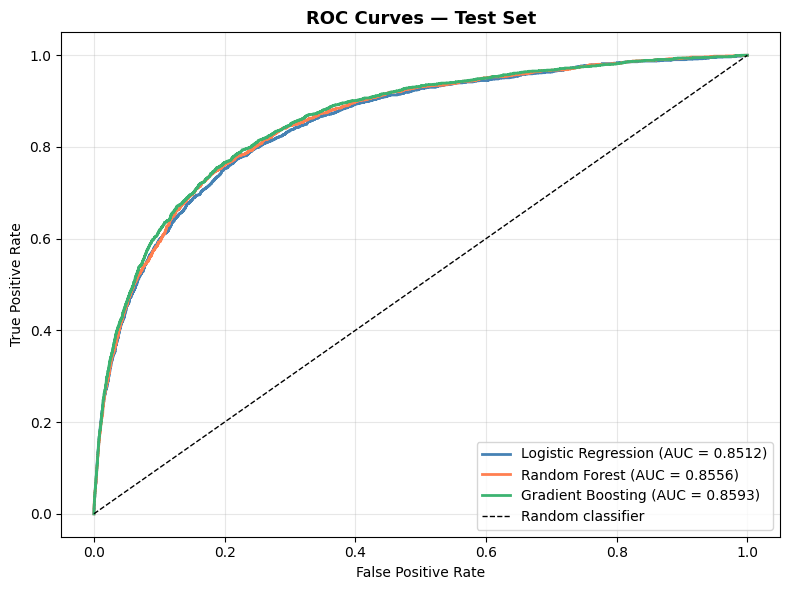

In [18]:
plt.figure(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.4f})", linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.4 Precision-Recall Curves

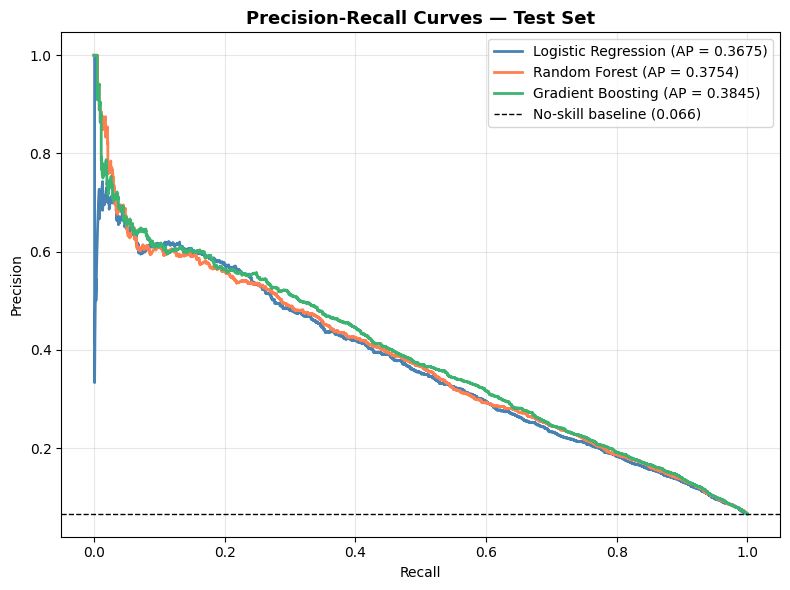

In [19]:
plt.figure(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall_vals, precision_vals, label=f"{name} (AP = {ap:.4f})", linewidth=2, color=color)

baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
            label=f'No-skill baseline ({baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Test Set', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.5 Confusion Matrices

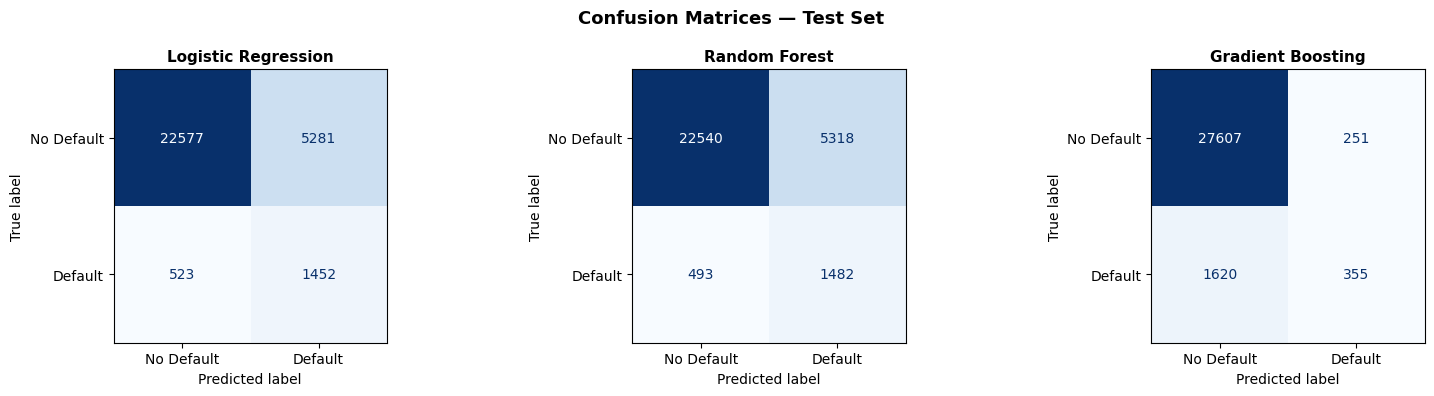

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.6 Summary Table

In [21]:
summary = pd.DataFrame({
    name: {
        'CV AUC Mean' : res['cv_auc'].mean(),
        'CV AUC Std'  : res['cv_auc'].std(),
        'Test AUC'    : res['test_auc'],
        'F1'          : res['f1'],
        'Precision'   : res['precision'],
        'Recall'      : res['recall'],
    }
    for name, res in results.items()
}).T

print(summary.round(4))

                     CV AUC Mean  CV AUC Std  Test AUC     F1  Precision  \
Logistic Regression       0.8586      0.0037    0.8512 0.3335     0.2157   
Random Forest             0.8640      0.0038    0.8556 0.3378     0.2179   
Gradient Boosting         0.8665      0.0037    0.8593 0.2751     0.5858   

                     Recall  
Logistic Regression  0.7352  
Random Forest        0.7504  
Gradient Boosting    0.1797  


---
## 12. Feature Importance — Best Model

In [22]:
best_name = max(results, key=lambda x: results[x]['test_auc'])
best_pipe = results[best_name]['pipeline']
print(f'Best model by test AUC: {best_name}  ({results[best_name]["test_auc"]:.4f})')

Best model by test AUC: Gradient Boosting  (0.8593)


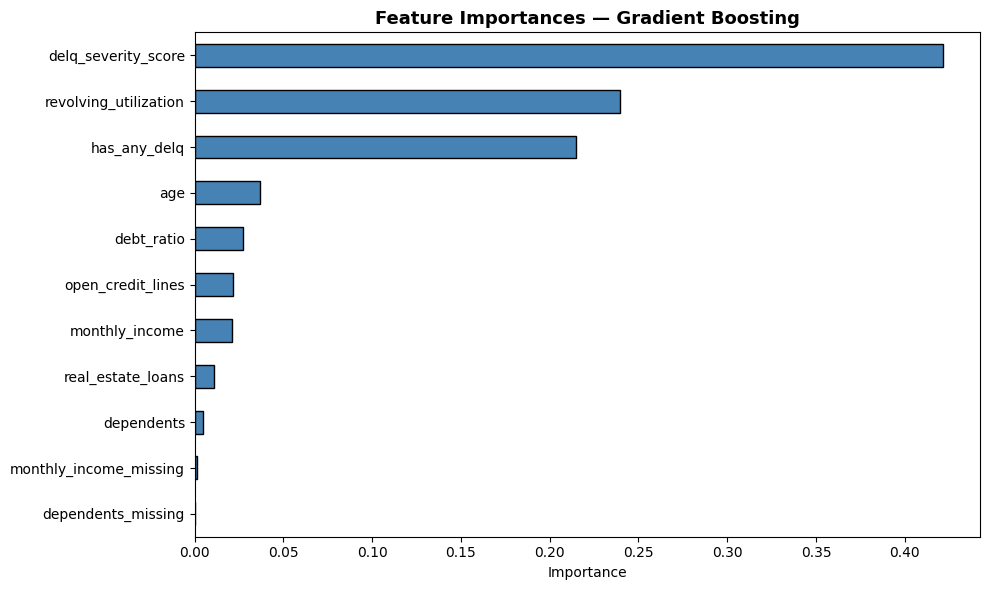

In [23]:
final_model = best_pipe.named_steps['model']

base_features = X_train.columns.tolist()
flag_features = [c + '_missing' for c in COLS_TO_FLAG]
all_features  = base_features + flag_features

if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    all_features = all_features[:len(importances)]
    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'coef_'):
    all_features = all_features[:len(final_model.coef_[0])]
    coefs = pd.Series(final_model.coef_[0], index=all_features).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    bar_colors = ['tomato' if c > 0 else 'steelblue' for c in coefs.values]
    coefs.plot(kind='barh', color=bar_colors, edgecolor='black')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'Coefficients — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()

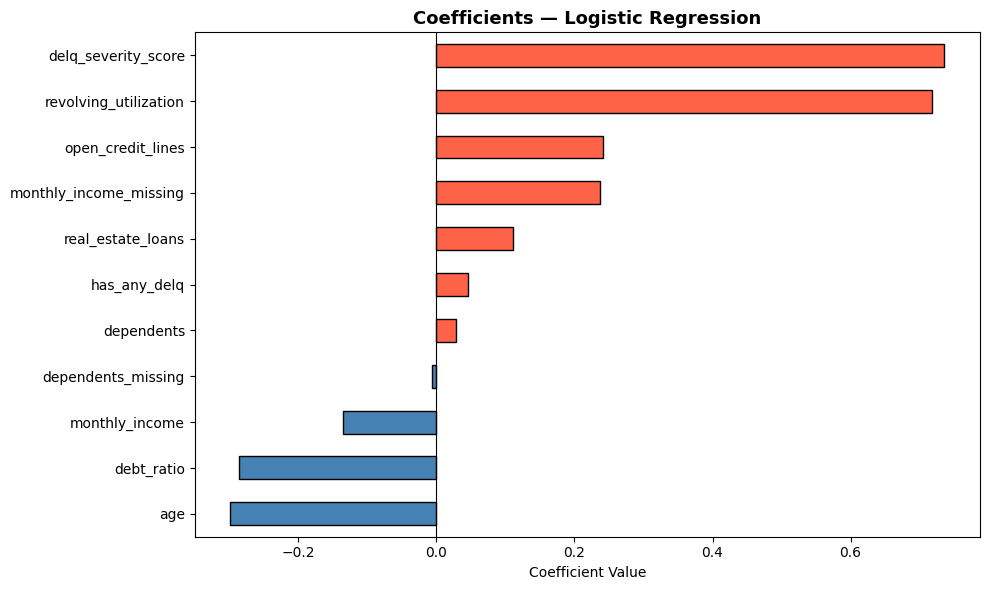

age                      -0.2982
debt_ratio               -0.2851
monthly_income           -0.1357
dependents_missing       -0.0061
dependents                0.0281
has_any_delq              0.0461
real_estate_loans         0.1110
monthly_income_missing    0.2368
open_credit_lines         0.2414
revolving_utilization     0.7184
delq_severity_score       0.7357
dtype: float64


In [24]:
lr_pipe = results['Logistic Regression']['pipeline']
lr_model = lr_pipe.named_steps['model']

base_features = X_train.columns.tolist()
flag_features = [c + '_missing' for c in COLS_TO_FLAG]
all_features  = base_features + flag_features
all_features  = all_features[:len(lr_model.coef_[0])]

coefs = pd.Series(lr_model.coef_[0], index=all_features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bar_colors = ['tomato' if c > 0 else 'steelblue' for c in coefs.values]
coefs.plot(kind='barh', color=bar_colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Coefficients — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(coefs.round(4))

In [25]:
print(X_train['debt_ratio'].describe())
print()
print('99th percentile:', X_train['debt_ratio'].quantile(0.99))
print('95th percentile:', X_train['debt_ratio'].quantile(0.95))
print('95th percentile:', X_train['debt_ratio'].quantile(0.76))

count   119332.0000
mean       357.9970
std       2214.8691
min          0.0000
25%          0.1796
50%          0.3702
75%          0.8792
max     329664.0000
Name: debt_ratio, dtype: float64

99th percentile: 4933.690000000002
95th percentile: 2450.0
95th percentile: 0.96672216944


---
## 13. Save Best Pipeline

In [26]:
import joblib

joblib.dump(best_pipe, 'best_pipeline_v2.pkl')
print(f'Saved: best_pipeline_v2.pkl')
print(f'Model : {best_name}')
print(f'AUC   : {results[best_name]["test_auc"]:.4f}')
print(f'F1    : {results[best_name]["f1"]:.4f}')
print(f'Recall: {results[best_name]["recall"]:.4f}')

Saved: best_pipeline_v2.pkl
Model : Gradient Boosting
AUC   : 0.8593
F1    : 0.2751
Recall: 0.1797


In [27]:
# Verify
loaded = joblib.load('best_pipeline_v2.pkl')
print('Loaded AUC:', roc_auc_score(y_test, loaded.predict_proba(X_test)[:, 1]).round(4))

AttributeError: 'float' object has no attribute 'round'